# Part A — Data Preparation

In [1]:
# Importing libraries

import pandas as pd

In [2]:
# Loading datasets

df1 = pd.read_csv("historical_data.csv")
df2 = pd.read_csv("fear_greed_index.csv")

In [4]:
# Preview of the both datasets
df1.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
df2.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [10]:
# Structure of both the datasets

print("Historical Data = ", df1.shape)
print("Fear greed data = ", df2.shape)

Historical Data =  (211224, 16)
Fear greed data =  (2644, 4)


In [27]:
# Columns
df1.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp']

In [28]:
df2.columns.tolist()

['timestamp', 'value', 'classification', 'date']

In [47]:
# datatypes
print(df1.dtypes)

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST               object
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp                  float64
trade_datetime      datetime64[ns]
date                        object
dtype: object


In [48]:
print(df2.dtypes)

timestamp                  int64
value                      int64
classification            object
date                      object
sentiment_date    datetime64[ns]
dtype: object


In [12]:
# Check missing values
print(df1.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [13]:
print(df1.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [14]:
# Checking duplicates

In [20]:
print("Historical data = ", df1.duplicated().sum())

Historical data =  0


In [21]:
print("Fear greed data = ", df2.duplicated().sum())

Fear greed data =  0


### Date conversion(Data Handling)

In [49]:
# Clean column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Convert to datetime
df1['trade_datetime'] = pd.to_datetime(df1['Timestamp IST'], errors='coerce')
df2['sentiment_date'] = pd.to_datetime(df2['date'], errors='coerce')

# Create common date column
df1['date'] = df1['trade_datetime'].dt.date
df2['date'] = df2['sentiment_date'].dt.date

### Merging the Datasets

In [30]:
# Merge trader data with sentiment data
merged_data = pd.merge(
    df1,
    df2[['date', 'classification', 'value']],
    on='date',
    how='left'
)

# Check merged data
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_datetime,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0


In [32]:
# Verify
merged_data[['Timestamp IST', 'date', 'classification']].head()

,Timestamp IST,date,classification
0,02-12-2024 22:50,2024-02-12,Greed
1,02-12-2024 22:50,2024-02-12,Greed
2,02-12-2024 22:50,2024-02-12,Greed
3,02-12-2024 22:50,2024-02-12,Greed
4,02-12-2024 22:50,2024-02-12,Greed


In [33]:
merged_data['classification'].value_counts()

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

### Saving the merge file

In [34]:
merged_data.to_csv("merged_data.csv", index=False)

In [35]:
# verify

In [36]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_datetime,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12 22:50:00,2024-02-12,Greed,70.0


### Created the key metrics:

#### Metric 1: Daily PnL 

In [38]:
daily_pnl = merged_data.groupby('date')['Closed PnL'].sum().reset_index()

In [39]:
daily_pnl.head()

,date,Closed PnL
0,2023-01-05,0.000000
1,2023-05-12,0.000000
2,2024-01-01,-129.531460
3,2024-01-02,0.000000
4,2024-01-03,8244.241409


#### Metric 2: Number of Trades per Day

In [41]:
daily_trades = merged_data.groupby('date').size().reset_index(name='trade_count')

In [42]:
daily_trades.head()

,date,trade_count
0,2023-01-05,3
1,2023-05-12,9
2,2024-01-01,18
3,2024-01-02,6
4,2024-01-03,137


#### Metric 3: Win Rate

In [50]:
# Step 1: Create win/loss column
merged_data['is_win'] = merged_data['Closed PnL'] > 0

In [51]:
# Step 2: Calculate daily win rate
daily_win_rate = merged_data.groupby('date')['is_win'].mean().reset_index()

In [52]:
# verify
daily_win_rate.head()

,date,is_win
0,2023-01-05,0.000000
1,2023-05-12,0.000000
2,2024-01-01,0.055556
3,2024-01-02,0.000000
4,2024-01-03,0.934307


#### Metric 4: Average Trade Size (USD)

In [53]:
# Step: Convert and calculate

In [54]:
# Converting to numeric 
merged_data['Size USD'] = pd.to_numeric(merged_data['Size USD'], errors='coerce')

# Average trade size per day
avg_trade_size = merged_data.groupby('date')['Size USD'].mean().reset_index()

In [55]:
avg_trade_size.head()

,date,Size USD
0,2023-01-05,159.000000
1,2023-05-12,5556.203333
2,2024-01-01,14679.973889
3,2024-01-02,334.696667
4,2024-01-03,3452.370073


#### Metric 5: Long / Short Ratio

In [56]:
# Step 1: Check values in Side column
merged_data['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

#### Metric 5: Long / Short Ratio

In [58]:
# Step: Calculating daily Buy/Sell ratio

In [59]:
# Created Buy/Sell indicator
merged_data['is_buy'] = merged_data['Side'] == 'BUY'

# Calculate daily buy ratio
daily_buy_ratio = merged_data.groupby('date')['is_buy'].mean().reset_index()

In [60]:
daily_buy_ratio.head()

,date,is_buy
0,2023-01-05,1.000000
1,2023-05-12,0.777778
2,2024-01-01,0.555556
3,2024-01-02,1.000000
4,2024-01-03,0.270073


#### Metric 6 - Direction (Long vs Short Behavior)

In [62]:
merged_data['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

Observation Notice in the dataset:

Direction column is:

Mixed (Open Long, Close Long, Buy, Sell, etc.)
Not clean enough for direct ratio calculation, 

thats why we need to 
create Final Metric (Refined): Long vs Short % per day

In [63]:
daily_long_short = merged_data.groupby('date')['is_buy'].mean().reset_index()aa

In [64]:
daily_long_short.head()

,date,is_buy
0,2023-01-05,1.000000
1,2023-05-12,0.777778
2,2024-01-01,0.555556
3,2024-01-02,1.000000
4,2024-01-03,0.270073


The above result shows:
    
1.0 → 100% BUY (fully long bias)

0.77 → mostly BUY

0.27 → mostly SELL (short bias)

# Part B - Analysis

### 1. Does performance differ between Fear vs Greed days?

In [67]:
performance_by_sentiment = merged_data.groupby('classification').agg(
    total_pnl = ('Closed PnL', 'sum'),
    avg_pnl = ('Closed PnL', 'mean'),
    win_rate = ('is_win', 'mean'),
    total_trades = ('Trade ID', 'count')
).reset_index()

performance_by_sentiment

,classification,total_pnl,avg_pnl,win_rate,total_trades
0,Extreme Fear,4.399937e+03,1.891632,0.292777,2326
1,Extreme Greed,1.156894e+06,205.816345,0.553282,5621
2,Fear,1.779226e+06,128.287950,0.381787,13869
3,Greed,6.096325e+05,53.988003,0.435707,11292
4,Neutral,7.465674e+04,27.088803,0.494920,2756


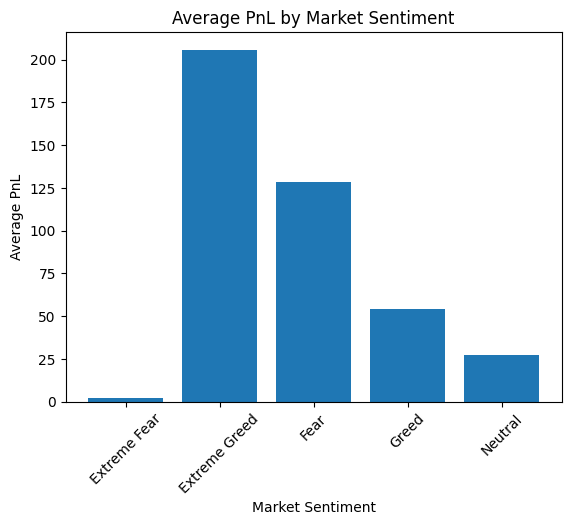

In [69]:
# Visualizing Performance by Sentiment

import matplotlib.pyplot as plt

# Bar chart for average PnL
plt.figure()
plt.bar(performance_by_sentiment['classification'], performance_by_sentiment['avg_pnl'])

plt.xlabel('Market Sentiment')
plt.ylabel('Average PnL')
plt.title('Average PnL by Market Sentiment')

plt.xticks(rotation=45)
plt.show()

Insight:

Traders perform best during Extreme Greed conditions, where average PnL is the highest. In contrast, performance is lowest during Extreme Fear, suggesting traders struggle to make profits when the market is very fearful.

### 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

-> Divided the question into:

    Trade frequency 
    
    Long/Short bias
    
    Position size 

In [70]:
# Trades per Sentiment
trades_by_sentiment = merged_data.groupby('classification').size().reset_index(name='trade_count')

trades_by_sentiment

,classification,trade_count
0,Extreme Fear,2326
1,Extreme Greed,5621
2,Fear,13869
3,Greed,11292
4,Neutral,2756


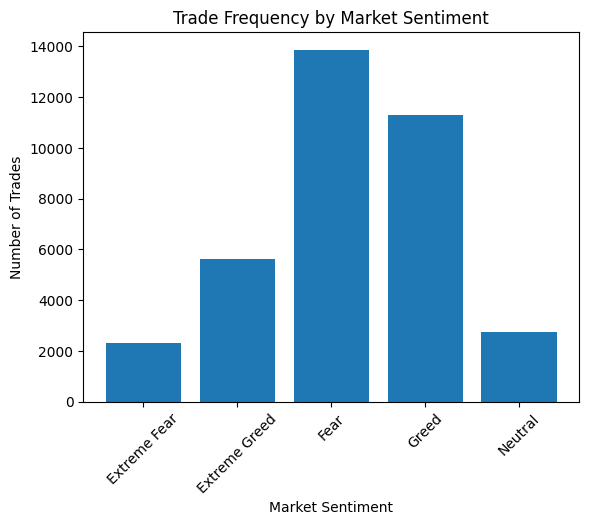

In [72]:
# Visualize 
import matplotlib.pyplot as plt

plt.figure()
plt.bar(trades_by_sentiment['classification'], trades_by_sentiment['trade_count'])

plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')
plt.title('Trade Frequency by Market Sentiment')

plt.xticks(rotation=45)
plt.show()

Insight:
   
   Traders are more active during Fear and Greed conditions, with the highest number of trades seen during Fear.
   
   In contrast, trading activity is lower during Extreme Fear, suggesting traders become more cautious in highly negative market conditions.

In [ ]:
# Long / Short Bias vs Sentiment - Calculate BUY % by sentiment

In [73]:
long_short_by_sentiment = merged_data.groupby('classification')['is_buy'].mean().reset_index()

long_short_by_sentiment

,classification,is_buy
0,Extreme Fear,0.502150
1,Extreme Greed,0.295499
2,Fear,0.526858
3,Greed,0.478835
4,Neutral,0.370102


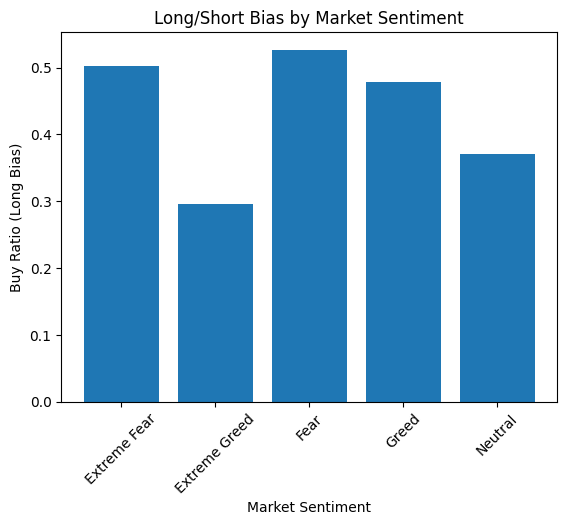

In [75]:
# Visualize

plt.figure()
plt.bar(long_short_by_sentiment['classification'], long_short_by_sentiment['is_buy'])

plt.xlabel('Market Sentiment')
plt.ylabel('Buy Ratio (Long Bias)')
plt.title('Long/Short Bias by Market Sentiment')

plt.xticks(rotation=45)
plt.show()

Insight (Long / Short Bias)

Traders show a stronger long (BUY) bias during Fear conditions, while during Extreme Greed, the buy ratio drops, indicating more short (SELL) activity. This suggests traders may take more contrarian or profit-booking positions when the market becomes overly greedy.

In [76]:
# Position Size vs Sentiment - Average Position Size by sentiment

position_size_by_sentiment = merged_data.groupby('classification')['Size USD'].mean().reset_index()

position_size_by_sentiment

,classification,Size USD
0,Extreme Fear,4118.761840
1,Extreme Greed,3242.085086
2,Fear,5744.782685
3,Greed,5051.878829
4,Neutral,4332.202906


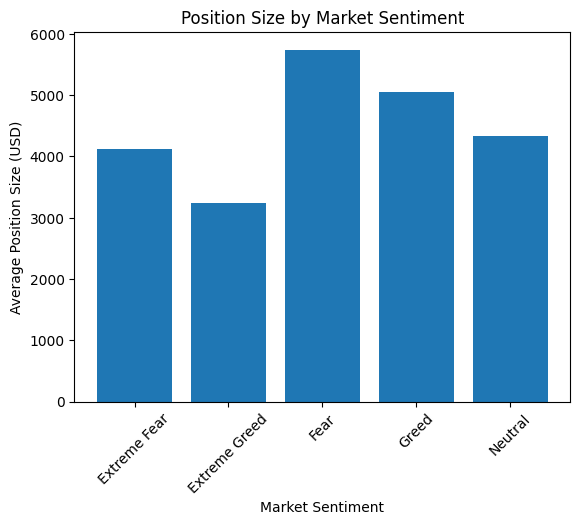

In [78]:
# Visualize

plt.figure()
plt.bar(position_size_by_sentiment['classification'], position_size_by_sentiment['Size USD'])

plt.xlabel('Market Sentiment')
plt.ylabel('Average Position Size (USD)')
plt.title('Position Size by Market Sentiment')

plt.xticks(rotation=45)
plt.show()

Insight:
    
Traders take larger position sizes during Fear and Greed conditions, with the highest average size seen during Fear. In comparison, position sizes are smaller during Extreme Greed, suggesting traders may become more cautious or reduce risk when the market is overly optimistic.

### 3. Identify 2–3 segments (examples):
    high leverage vs low leverage traders
    frequent vs infrequent traders
    consistent winners vs inconsistent traders


#### a) high leverage vs low leverage traders:
    Leverage-based segmentation could not be performed as the dataset does not contain leverage-related information.

#### b) Segment 1: Frequent vs Infrequent Traders

In [80]:
# Step: Calculating trades per trader

trades_per_trader = merged_data.groupby('Account').size().reset_index(name='trade_count')
trades_per_trader.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [82]:
# Classify Frequent vs Infrequent Traders - Created segments

In [83]:
# Find median (threshold)
threshold = trades_per_trader['trade_count'].median()

# Creating new column
trades_per_trader['trader_type'] = 'Infrequent'

# Update Frequent traders
trades_per_trader.loc[trades_per_trader['trade_count'] > threshold, 'trader_type'] = 'Frequent'

# Check result
trades_per_trader.head()

,Account,trade_count,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent


In [84]:
# Comparing Performance (Frequent vs Infrequent) - Merge segment back to main data

merged_data = merged_data.merge(
    trades_per_trader[['Account', 'trader_type']],
    on='Account',
    how='left'
)

In [88]:
# verify
merged_data[['Account', 'trader_type']].head()

,Account,trader_type
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent


In [87]:
# Checking counts
merged_data['trader_type'].value_counts()

trader_type
Frequent      186957
Infrequent     24267
Name: count, dtype: int64

In [ ]:
# Comparing the Performance (Frequent vs Infrequent) - Calculate the performance

In [89]:
performance_by_trader_type = merged_data.groupby('trader_type').agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    total_trades=('Trade ID', 'count')
).reset_index()

performance_by_trader_type

,trader_type,avg_pnl,win_rate,total_trades
0,Frequent,42.493421,0.415438,186957
1,Infrequent,96.943024,0.379116,24267


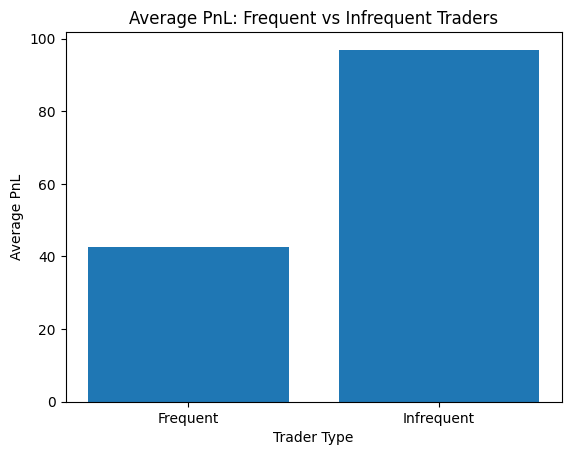

In [90]:
# Visualize
plt.figure()
plt.bar(performance_by_trader_type['trader_type'], performance_by_trader_type['avg_pnl'])

plt.xlabel('Trader Type')
plt.ylabel('Average PnL')
plt.title('Average PnL: Frequent vs Infrequent Traders')

plt.show()

Insight:
    
Infrequent traders earn higher average PnL per trade, but frequent traders have a slightly better win rate.

This suggests that frequent traders rely on consistency, while infrequent traders may take fewer but higher-impact trades.

#### c) consistent winners vs inconsistent traders


In [92]:
# Calculate win rate per trader

win_rate_per_trader = merged_data.groupby('Account')['is_win'].mean().reset_index()
win_rate_per_trader.head()

,Account,is_win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [95]:
# Classify Consistent vs Inconsistent

In [96]:
# Find median win rate
threshold = win_rate_per_trader['is_win'].median()

# Create new column
win_rate_per_trader['trader_consistency'] = 'Inconsistent'

# Update Consistent traders
win_rate_per_trader.loc[
    win_rate_per_trader['is_win'] > threshold,
    'trader_consistency'
] = 'Consistent'

# Check result
win_rate_per_trader.head()

,Account,is_win,trader_consistency
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Inconsistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Inconsistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Consistent


In [ ]:
# Merge this into main data

In [97]:
merged_data = merged_data.merge(
    win_rate_per_trader[['Account', 'trader_consistency']],
    on='Account',
    how='left'
)

In [98]:
# verify
merged_data[['Account', 'trader_consistency']].head()

,Account,trader_consistency
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Consistent


In [99]:
# Compare Performance (Consistent vs Inconsistent)

performance_by_consistency = merged_data.groupby('trader_consistency').agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    total_trades=('Trade ID', 'count')
).reset_index()

performance_by_consistency

,trader_consistency,avg_pnl,win_rate,total_trades
0,Consistent,38.783637,0.471759,122427
1,Inconsistent,62.488537,0.327860,88797


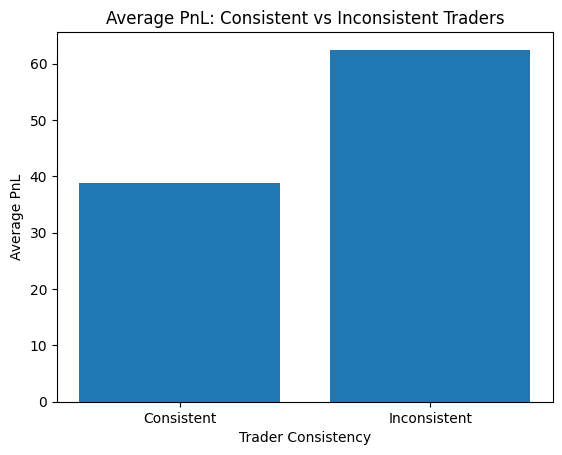

In [100]:
# Chart  visual
plt.figure()
plt.bar(performance_by_consistency['trader_consistency'], performance_by_consistency['avg_pnl'])

plt.xlabel('Trader Consistency')
plt.ylabel('Average PnL')
plt.title('Average PnL: Consistent vs Inconsistent Traders')

plt.show()

Insight:

    Consistent traders have a higher win rate, but their average PnL is lower compared to inconsistent traders. 
    
    This suggests that inconsistent traders take higher-risk trades, which sometimes lead to bigger profits but with lower success rates.

### 4. Provide at least 3 insights backed by charts/tables - Strategy Recommendations

#### a) Stategy 1

During Extreme Greed conditions, traders can consider increasing position sizes, as average PnL is highest in this phase. However, caution is advised during Extreme Fear, where performance drops, so reducing exposure or trading frequency may help minimize losses.

#### b) Strategy 2 (Based on Trader Behavior)

Frequent traders tend to have a higher win rate but lower average PnL, while infrequent traders generate higher profits per trade. A balanced approach can be to trade selectively (like infrequent traders) but maintain consistency by avoiding overtrading and focusing on high-quality setups.

#### c) Strategy 3 (Based on Sentiment + Trading Behavior)

During Fear conditions, traders show a higher long (BUY) bias, which suggests potential rebound expectations. Traders can consider cautiously taking long positions during Fear phases, while being more defensive or considering short positions during Extreme Greed, where buy activity decreases and profit-booking behavior increases.